In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit
from scipy.interpolate import griddata


### Variable

In [2]:
dim = 100 # Dimension de la matrice dans laquelle on va solutionner l'ED
I = 2 # Courant injecté dans le sol
hx = 1 # pas spatial
hy = 1 # pas spatial

x = np.linspace(0, dim, dim) # Prépare l'axe x pour faire le grid
y = np.linspace(0, dim, dim) # Prépare l'axe y pour faire le grid

xx, yy = np.meshgrid(x, y) # Crée le grid

# Première position des électrodes A M N B

# Les électrodes A et B sont les électrodes qui injecte le courants dans le sol
A = (dim-2, (dim//2)-4)
B = (dim-2, (dim//2)+4)

# Les électrodes M et N sont celles qui mesures la différence de potentiel apparente
M = (dim-2, (dim//2)-2)
N = (dim-2, (dim//2)+2)


### On met une matrice de conductivité

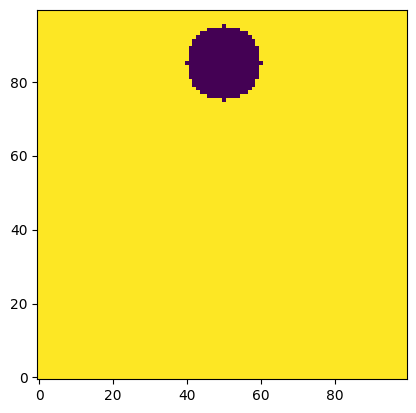

In [3]:
sigma_init = 0.01*np.ones((dim, dim))#np.random.uniform(low=1, high=10, size=(dim, dim)) # Initialise une matrice de conductivité

# Les deux prochaines ligne sont pour créer une inclusion dans le sol
xx, yy = np.meshgrid(np.arange(dim), np.arange(dim), indexing='ij')
sigma_init[(xx-85)**2 + (yy-50)**2 <= 10**2] = 1/1000


# sigma_init[: 90, dim//2 - 50: dim//2 + 50] = 1000

# J'initialise le potentiel
pot_init = np.zeros((dim, dim))

# Je fais une matrice de courant dans laquelle il n'y a que les point d'injection A et B.
courant_init = np.zeros((dim, dim))
courant_init[A[0], A[1]] = I
courant_init[B[0], B[1]] = -I

plt.figure()
plt.imshow(sigma_init, origin='lower')



### Calcul du potentiel

$$ \nabla \cdot (\sigma\nabla V) = -I\delta(\vec{r}-\vec{r_s})$$

On sait que $J = \sigma\nabla V$, donc
$$ \nabla \cdot J = -I\delta(\vec{r}-\vec{r_s})$$

On développe $ \nabla \cdot J $,
$$ \frac{\partial J}{\partial x} + \frac{\partial J}{\partial y} = -I\delta(\vec{r}-\vec{r_s})$$

Comme on veut le flux de courant entre deux pixels, on peut dire que
$$ \frac{\partial J}{\partial x} = \frac{J_{i+1/2, j} - J_{i-1/2, j}}{\Delta x},\text{  } \frac{\partial J}{\partial y} = \frac{J_{i, j+1/2} - J_{i, j-1/2}}{\Delta y} $$

Comme le flux entre deux pixels est 


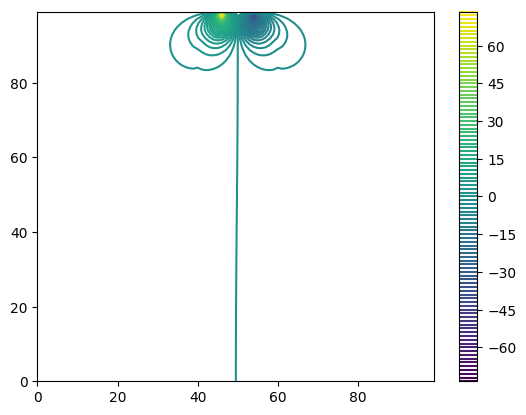

In [4]:
import numpy as np
import numba

@numba.njit(fastmath=True, parallel=True)
def compute_pot(V, V_k, Sigma, I): # Fonction pour calculer le potentiel en tout point
    l = V.shape[0] # longueur de ligne et de colonne pour itérer
    h2 = 1.0  # h^2

    for j in numba.prange(1, l-1):
        for i in range(1, l-1):

            s = Sigma[j, i] # Point centrale d'analyse

            sip = Sigma[j, i+1] # Droite
            sim = Sigma[j, i-1] # Gauche
            sjp = Sigma[j+1, i] # Haut
            sjm = Sigma[j-1, i] # Bas

            # Moyenne harmonique pour le calcul des demi pas
            sigma_ifhs = 2*s*sip / (s + sip) # demi pas à droite
            sigma_ibhs = 2*s*sim / (s + sim) # demi pas à gauche
            sigma_jfhs = 2*s*sjp / (s + sjp) # demi pas en haut
            sigma_jbhs = 2*s*sjm / (s + sjm) # demi pas en bas

            # dénominateur
            deno = sigma_ifhs + sigma_ibhs + sigma_jfhs + sigma_jbhs

            # numérateur
            num = I[j, i]*h2 + sigma_ifhs*V_k[j, i+1] + sigma_ibhs*V_k[j, i-1] + sigma_jfhs*V_k[j+1, i] + sigma_jbhs*V_k[j-1, i]

            # Valeur des pixel dans V
            V[j, i] = num / deno

    return V

# Calcul l'erreur
@numba.njit(fastmath=True)
def compute_error(V, V_k):
    err = 0.0
    for j in range(V.shape[0]):
        for i in range(V.shape[1]):
            d = V[j, i] - V_k[j, i]
            err += d*d
    return np.sqrt(err)

# Condition aux frontières
@numba.njit(fastmath=True)
def apply_bc(V, DIM):
    # conditions limites
    V[0, :] = V[1, :]#V[0, :] = 0
    V[-1, :] = 0#V[-1, :] = V[-2, :]
    V[:, 0] = V[:, 1]
    V[:, DIM-1] = V[:, DIM-2]

# Itération du calcul de potentiel
@numba.njit(fastmath=True)
def find_pot(V, Sigma, I, DIM, tol=1e-5, niter=1000000):

    for _ in range(niter):

        V_k = V.copy()

        apply_bc(V, DIM)

        compute_pot(V, V_k, Sigma, I)

        error = compute_error(V, V_k)

        if error < tol:
            break

    return V

Voltage = find_pot(pot_init, sigma_init, courant_init, DIM=dim)

# print(f"Nombre d'itérations: {it}")
# print(f"Erreur: {error}")


plt.figure()
# plt.imshow(Voltage, origin='lower')
plt.contour(Voltage, levels=100)
# plt.imshow(pot)
plt.colorbar()
                

### Mesure de la résistivité apparente du sol

La résistivité apparente est la résistivité tel que mesuré à la surface du sol, c'est pourquoi on a besoin d'une méthode d'inversion pour pouvoir passer d'une matrice de résistivité apparente à une matrice de résistivité "réelle" dans le sol. 

In [5]:
import numpy as np
from joblib import Parallel, delayed

def coord_schlumb(A_i, B_i, max_dist):
    # Fonction pour avoir les positions des électrodes A et B
    A_to_move = A_i[1]
    B_to_move = B_i[1]
    A_list = []
    B_list = []
    for i in range(2, max_dist, 2):
        A = A_to_move - i
        B = B_to_move + i
        A_list.append(A)
        B_list.append(B)

    return list(zip(A_list, B_list))

c = coord_schlumb(A, B, 45)

# Calcul la résistivité apparente et la distance AB/2 pour un couple AB
def compute_one_ab(a, b, dimension, cond, I, M, N):
    # Injection courant
    I0 = np.zeros((dimension, dimension))
    I0[98, a] = I
    I0[98, b] = -I

    # Solveur
    V = find_pot(np.zeros((dimension, dimension)), cond, I0, DIM=dimension)

    # Différence de potentiel
    dV = V[M[0], M[1]] - V[N[0], N[1]]

    # Distance AB
    AB = abs(b - a)
    AB_2 = AB / 2

    # Distance MN
    MN_dist = abs(M[1] - N[1])
    MN_term = (MN_dist / 2)**2

    # Facteur géométrique
    K = np.pi * ((AB_2**2 - MN_term) / MN_dist)

    # Résistivité apparente
    rho = K * dV / I

    return rho, AB_2

# Calcul la résistivité apparente pour toute les coordonnées
def app_res_parallel(coord_ab, dimension, cond, I, M, N, n_jobs=-1):

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_one_ab)(a, b, dimension, cond, I, M, N)
        for (a, b) in coord_ab
    )

    rho_app, AB_2 = zip(*results)

    return np.array(rho_app), np.array(AB_2)

In [6]:
# On collecte la résistivité apparente et les mesures de AB/2 au centre de notre ligne de levé
rho_a, ab2 = app_res_parallel(c, dim, sigma_init, I, M, N)

Text(0.5, 0, 'Demi-distance entre les électrodes [m]')

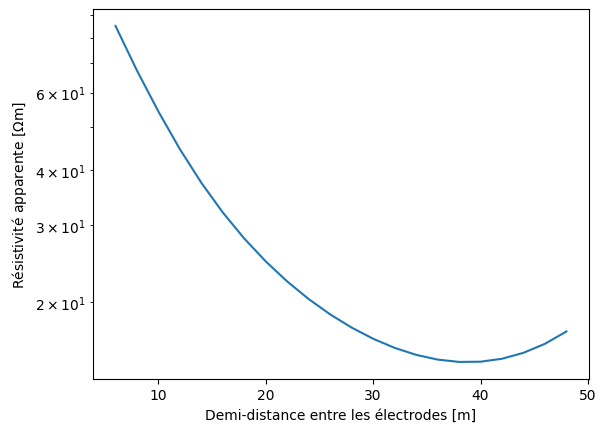

In [7]:
plt.figure()
# plt.contourf(xx, yy, V_[0], levels=200)
plt.plot(ab2, rho_a)
plt.yscale('log')
plt.ylabel(r"Résistivité apparente [$\Omega$m]")
plt.xlabel("Demi-distance entre les électrodes [m]")

### On trouve la pseudo-section

La pseudo-section est un "mapping" de la résistivité apparent du sous-sol. On la trouve en refaisant les calculs de résistivité apparente mais sur toute la longueur de la ligne de levé et pour plusieurs distance AB, afin d'avoir une plus grande profondeur de pénétration dans le sol.

In [8]:
# On trouve la pseudo-section
def pseudo_section(dimension, cond, I):
    rho = [] # initialise une liste de résistivité apparente
    x = [] # initialise une liste de position en x
    z = [] # initialise une liste de position en z (profondeur)
    electrode_pos = []

    # Premiers points de la ligne de levé
    A_i = [dimension-2, 2]
    M_i = [dimension-2, 4]
    N_i = [dimension-2, 6]
    B_i = [dimension-2, 8]

    # Points modifiable
    A_i_modif = A_i.copy()
    B_i_modif = B_i.copy()
    M_i_modif = M_i.copy()
    N_i_modif = N_i.copy()

    # La loop continue tant que la distance AB n'atteint pas près de la dimension de la matrice initiale
    while B_i_modif[1] - A_i_modif[1] <= dimension-4:

        # On isole les positions en x des électrodes
        a, b, m, n = A_i_modif[1], B_i_modif[1], M_i_modif[1], N_i_modif[1]

        electrode_pos.append((a//2, m//2, n//2, b//2))

        print(B_i_modif[1] - A_i_modif[1])
        print(a, b, m, n)

        # Initialise une nouvelle matrice de courant
        I0 = np.zeros((dimension, dimension))

        # Initialise une nouvelle matrice potentiel
        V_i = np.zeros((dimension, dimension))
        
        # On place les point d'injections de courant aux point A et B
        I0[A_i_modif[0], A_i_modif[1]]=I
        I0[B_i_modif[0], B_i_modif[1]]=-I

        # On trouve la matrice de potentiel
        V = find_pot(V_i, cond, I0, DIM=dimension)

        # On trouve la différence de potentiel entre les point M et N
        V_MN = V[M_i_modif[0], M_i_modif[1]] - V[N_i_modif[0], N_i_modif[1]]#pot_for_schlumb(V, M_i_modif, N_i_modif)

        # On trouve la facteur géométrique
        K = np.pi * (((abs(b-a)/2)**2 - (abs(m-n)/2)**2) / abs(m-n))
        
        # On trouve et on ajoute la position en x à la liste
        x_i = (m + n)//2
        x.append(x_i)

        # On trouve et on ajoute la position en z à la liste
        z_i = abs(b-a)*0.19
        z.append(z_i)

        # On trouve et on ajoute la valeur de résistivité apparent à la liste
        rho.append(K*V_MN/I)

        # On ajoute 2 à la position des électrodes pour qu'ils se déplacent de deux pixels
        A_i_modif[1] += 2
        B_i_modif[1] += 2
        M_i_modif[1] += 2
        N_i_modif[1] += 2

        # Condition de fin de ligne
        if B_i_modif[1] >= dimension-2:
            # On ramène à la position de départ et on ajoute un écart entre les électrodes
            A_i_modif[1] = 2
            B_i_modif[1] = B_i[1] + 4
            M_i_modif[1] = M_i[1] + 2
            N_i_modif[1] = N_i[1] + 2
            A_i[1] += 2
            B_i[1] += 4
            M_i[1] += 2
            N_i[1] += 2

    # On retourne les positions et la résistivité
    return np.array(x), np.array(z), np.array(rho)

In [9]:
pseudo_section_array = pseudo_section(dim, sigma_init, I)

6
2 8 4 6
6
4 10 6 8
6
6 12 8 10
6
8 14 10 12
6
10 16 12 14
6
12 18 14 16
6
14 20 16 18
6
16 22 18 20
6
18 24 20 22
6
20 26 22 24
6
22 28 24 26
6
24 30 26 28
6
26 32 28 30
6
28 34 30 32
6
30 36 32 34
6
32 38 34 36
6
34 40 36 38
6
36 42 38 40
6
38 44 40 42
6
40 46 42 44
6
42 48 44 46
6
44 50 46 48
6
46 52 48 50
6
48 54 50 52
6
50 56 52 54
6
52 58 54 56
6
54 60 56 58
6
56 62 58 60
6
58 64 60 62
6
60 66 62 64
6
62 68 64 66
6
64 70 66 68
6
66 72 68 70
6
68 74 70 72
6
70 76 72 74
6
72 78 74 76
6
74 80 76 78
6
76 82 78 80
6
78 84 80 82
6
80 86 82 84
6
82 88 84 86
6
84 90 86 88
6
86 92 88 90
6
88 94 90 92
6
90 96 92 94
10
2 12 6 8
10
4 14 8 10
10
6 16 10 12
10
8 18 12 14
10
10 20 14 16
10
12 22 16 18
10
14 24 18 20
10
16 26 20 22
10
18 28 22 24
10
20 30 24 26
10
22 32 26 28
10
24 34 28 30
10
26 36 30 32
10
28 38 32 34
10
30 40 34 36
10
32 42 36 38
10
34 44 38 40
10
36 46 40 42
10
38 48 42 44
10
40 50 44 46
10
42 52 46 48
10
44 54 48 50
10
46 56 50 52
10
48 58 52 54
10
50 60 54 56
10
52 62 56 

[np.int64(5), np.int64(7), np.int64(9), np.int64(11), np.int64(13), np.int64(15), np.int64(17), np.int64(19), np.int64(21), np.int64(23), np.int64(25), np.int64(27), np.int64(29), np.int64(31), np.int64(33), np.int64(35), np.int64(37), np.int64(39), np.int64(41), np.int64(43), np.int64(45), np.int64(47), np.int64(49), np.int64(51), np.int64(53), np.int64(55), np.int64(57), np.int64(59), np.int64(61), np.int64(63), np.int64(65), np.int64(67), np.int64(69), np.int64(71), np.int64(73), np.int64(75), np.int64(77), np.int64(79), np.int64(81), np.int64(83), np.int64(85), np.int64(87), np.int64(89), np.int64(91), np.int64(93), np.int64(7), np.int64(9), np.int64(11), np.int64(13), np.int64(15), np.int64(17), np.int64(19), np.int64(21), np.int64(23), np.int64(25), np.int64(27), np.int64(29), np.int64(31), np.int64(33), np.int64(35), np.int64(37), np.int64(39), np.int64(41), np.int64(43), np.int64(45), np.int64(47), np.int64(49), np.int64(51), np.int64(53), np.int64(55), np.int64(57), np.int64(5

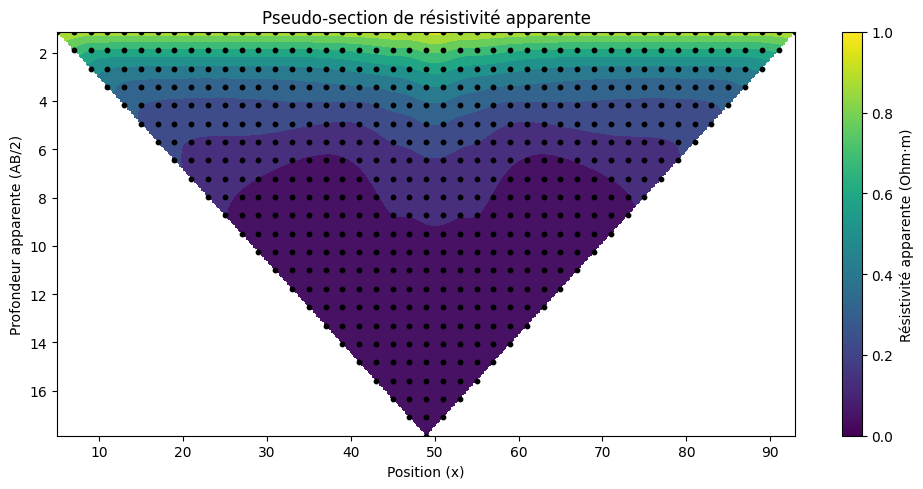

In [11]:

x, z, rho_app = pseudo_section_array

print(list(x))

# grille régulière
xi = np.linspace(x.min(), x.max(), 200)
zi = np.linspace(z.min(), z.max(), 200)

XI, ZI = np.meshgrid(xi, zi)

# interpolation
RHOI = griddata((x, z), rho_app, (XI, ZI), method='cubic')

plt.figure(figsize=(10, 5))

# contour rempli
plt.contourf(XI, ZI, RHOI, levels=10)
# plt.imshow(RHOI, origin='lower')

# points de mesure (optionnel mais pro)
plt.scatter(x, z, c='k', s=10)

plt.gca().invert_yaxis()  # profondeur vers le bas

plt.xlabel("Position (x)")
plt.ylabel("Profondeur apparente (AB/2)")

plt.title("Pseudo-section de résistivité apparente")

plt.colorbar(label="Résistivité apparente (Ohm·m)")

plt.tight_layout()
plt.show()

### Inversion

La prochaine étape serait l'inversion des données dans le sol. Probablement le plus compliqué mais essayons, sinon c'est pas si grave on a des beau graphiques.